In [256]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch.nn.functional as F

from hui_extended import logits_manual

MODEL_NAME = "./weiser/101M-0.4"

ModuleNotFoundError: No module named 'hui_extended'

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.config._attn_implementation = "eager"
model.eval()
print(model)

In [ ]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

In [ ]:
math_expressions = [
    "Ten plus five equals to ",
    "Eight minus three equals to ",
    "Six times two equals to ",
    "Nine plus seven equals to ",
    "Four times one equals to ",
    "Twelve minus six equals to ",
    "Three times five equals to ",
    "Seven plus zero equals to ",
    "Two times nine equals to ",
    "Eleven minus four equals to "
]

sentences = [
    "Cats love fish because of ",
    "Dogs chase balls because of ",
    "Birds build nests because of ",
    "Bears eat honey because of ",
    "Cows chew grass because of ",
    "Frogs catch flies because of ",
    "Bees make honey because of ",
    "Monkeys love bananas because of ",
    "Spiders spin webs because of ",
    "Horses eat hay because of "
]

sample_num = 3

In [ ]:
prompt = sentences[sample_num]
sample_label = "other_" + str(sample_num)
SAMPLES_DIR = "./samples/"

In [ ]:

tokens = tokenizer.tokenize(prompt)
print(tokens)

ids = torch.tensor([tokenizer.convert_tokens_to_ids(tokens)])
print(ids)

In [ ]:
#with open(SAMPLES_DIR + 'samples.txt', 'a', encoding='utf-8') as f:
    # Записываем обе переменные, разделяя их пробелом, и ставим перенос строки \n
    #f.write(f"|{prompt}| - {sample_label}; {len(tokens)}\n")

In [ ]:
with torch.no_grad():
    outputs = model(ids,
                     output_attentions=True,
                     output_hidden_states=True,
                     return_dict=True)

attn = outputs.attentions[0]   # attention weights 0-го слоя, эталон для сверки
hs = outputs.hidden_states
embs_plus_pos = hs[0]          # ВНИМАНИЕ: в GPT-2 hidden_states[0] это уже wte+wpe (НЕ просто эмбеддинг токена)
l0 = hs[1]                     # эталонный выход после 0-го блока

print("attn shape:", attn.shape)
print("hidden_states[0] shape:", embs_plus_pos.shape)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

heads = attn[0].detach().cpu().to(torch.float32).numpy()
labels = tokenizer.convert_ids_to_tokens(ids[0])

for i, head_matrix in enumerate(heads):
    plt.figure(figsize=(6, 5))
    plt.title(f"Attention Head {i}")
    sns.heatmap(head_matrix, xticklabels=labels, yticklabels=labels)
    plt.show()

In [ ]:
# --- Шаг 1. Эмбеддинги: в GPT-2 нет RoPE, позиция добавляется явно ---
# x = wte(ids) + wpe(position_ids)

seq_len = ids.shape[1]
position_ids = torch.arange(seq_len).unsqueeze(0)  # [1, seq_len]

tok_emb = model.transformer.wte(ids)          # [1, seq, hidden]  -- "что за токен"
pos_emb = model.transformer.wpe(position_ids) # [1, seq, hidden]  -- "на какой он позиции"

x = tok_emb + pos_emb

print("max abs diff vs hidden_states[0] (эталон):",
      (x.float() - embs_plus_pos.float()).abs().max().item())

In [ ]:
# --- Шаг 2. LayerNorm перед attention (GPT-2: обычный LayerNorm, не RMSNorm) ---
block = model.transformer.h[0]   # аналог layer в Llama -- список блоков называется .h, не .layers

x_norm = block.ln_1(x)
print("x_norm shape:", x_norm.shape)

In [ ]:
# --- Шаг 3. Q, K, V одним проходом через c_attn, затем разрезаем ---
# В Llama это три разных Linear (q_proj/k_proj/v_proj).
# В GPT-2 это ОДИН Conv1D, который сразу выдаёт [Q | K | V] склеенными по последней размерности.

attn_module = block.attn

embed_dim = model.config.hidden_size       # он же n_embd
num_heads = model.config.num_attention_heads if hasattr(model.config, "num_attention_heads") else model.config.n_head
head_dim = embed_dim // num_heads

print("embed_dim:", embed_dim, "num_heads:", num_heads, "head_dim:", head_dim)

qkv = attn_module.c_attn(x_norm)  # [1, seq, 3*embed_dim]
q, k, v = qkv.split(embed_dim, dim=2)

print("q shape:", q.shape, "k shape:", k.shape, "v shape:", v.shape)

In [ ]:
# --- Шаг 4. Reshape на головы ---
# Важно: в GPT-2 НЕТ шага "применить RoPE" -- позиция уже учтена на шаге 1 через wpe.
# Поэтому здесь сразу reshape, без поворота векторов.

bsz = ids.shape[0]

def split_heads(t, num_heads, head_dim):
    new_shape = t.shape[:-1] + (num_heads, head_dim)
    t = t.view(new_shape)
    return t.permute(0, 2, 1, 3)   # [batch, num_heads, seq, head_dim]

q = split_heads(q, num_heads, head_dim)
k = split_heads(k, num_heads, head_dim)
v = split_heads(v, num_heads, head_dim)

print("q reshaped:", q.shape)

In [ ]:
# --- Шаг 5. Scores = Q*K^T / sqrt(head_dim) ---
scaling = attn_module.scaling   # GPT-2 хранит готовый коэффициент масштабирования в самом модуле
scores = torch.matmul(q, k.transpose(-1, -2)) * scaling
print("scores shape:", scores.shape)

# --- Шаг 6. Causal mask ---
# ВАЖНО: dtype маски должен совпадать с dtype scores (модель может быть в bfloat16/float16),
# иначе torch.matmul ниже упадёт с RuntimeError из-за несовпадения типов.
causal_mask = torch.full((seq_len, seq_len), float("-inf"), dtype=scores.dtype)
causal_mask = torch.triu(causal_mask, diagonal=1)
scores_masked = scores + causal_mask

# --- Шаг 7. Softmax -> веса внимания ---
attn_weights_manual = F.softmax(scores_masked, dim=-1)

print("max abs diff vs outputs.attentions[0] (эталон):",
      (attn_weights_manual.float() - attn[0].float()).abs().max().item())

In [ ]:
# --- Шаг 8. attn_weights @ V, затем склеиваем головы и c_proj ---
attn_out = torch.matmul(attn_weights_manual, v)        # [1, num_heads, seq, head_dim]
attn_out = attn_out.transpose(1, 2).contiguous()       # [1, seq, num_heads, head_dim]
attn_out = attn_out.reshape(bsz, seq_len, embed_dim)   # [1, seq, embed_dim]

attn_out = attn_module.c_proj(attn_out)                # Conv1D, БЕЗ транспонирования весов
print("attn_out shape:", attn_out.shape)

In [257]:
# --- Шаг 9. Первый residual connection ---
hidden_after_attn = x + attn_out   # x -- вход блока ДО ln_1, как и в Llama
print("hidden_after_attn shape:", hidden_after_attn.shape)

hidden_after_attn shape: torch.Size([1, 7, 704])


In [258]:
# --- Интерпретация: ближайшие токены словаря для hidden_after_attn ---
def nearest_tokens(hidden_states, embed_weight, tokenizer, top_k=5):
    hs = hidden_states[0]
    hs_norm = F.normalize(hs, dim=-1)
    emb_norm = F.normalize(embed_weight, dim=-1)
    sims = torch.matmul(hs_norm, emb_norm.T)

    results = []
    for pos in range(hs.shape[0]):
        top_vals, top_idx = torch.topk(sims[pos], top_k)
        top_tokens = tokenizer.convert_ids_to_tokens(top_idx.tolist())
        results.append(list(zip(top_tokens, top_vals.tolist())))
    return results

embed_weight = model.transformer.wte.weight.detach()
input_tokens = tokenizer.convert_ids_to_tokens(ids[0])

nearest = nearest_tokens(hidden_after_attn.detach(), embed_weight, tokenizer, top_k=5)

for pos, (orig_token, candidates) in enumerate(zip(input_tokens, nearest)):
    print(f"[{pos}] исходный токен: {orig_token!r}")
    for tok, sim in candidates:
        print(f"      {tok!r:20s} cos_sim={sim:.4f}")
    print()

[0] исходный токен: 'B'
      'B'                  cos_sim=0.3574
      'ĠB'                 cos_sim=0.2344
      'b'                  cos_sim=0.1982
      'M'                  cos_sim=0.1748
      'C'                  cos_sim=0.1572

[1] исходный токен: 'ears'
      'ears'               cos_sim=0.5312
      'eared'              cos_sim=0.2383
      'ear'                cos_sim=0.2285
      'earing'             cos_sim=0.2168
      'em'                 cos_sim=0.1396

[2] исходный токен: 'Ġeat'
      'Ġeat'               cos_sim=0.4453
      'Ġeating'            cos_sim=0.2676
      'Ġate'               cos_sim=0.2002
      'Ġeats'              cos_sim=0.1982
      'Ġdrink'             cos_sim=0.1963

[3] исходный токен: 'Ġhoney'
      'Ġhoney'             cos_sim=0.4258
      'ĠHoney'             cos_sim=0.2539
      'Ġbees'              cos_sim=0.1050
      'Ġsugar'             cos_sim=0.0894
      'ye'                 cos_sim=0.0840

[4] исходный токен: 'Ġbecause'
      'Ġbecause'  

In [259]:
x_norms = x.norm(dim=-1)              # [1, seq_len]
attn_out_norms = attn_out.norm(dim=-1)  # [1, seq_len]

for pos in range(x.shape[1]):
    ratio = attn_out_norms[0, pos].item() / x_norms[0, pos].item()
    print(f"[{pos}] ||x||={x_norms[0,pos].item():.3f}  "
          f"||attn_out||={attn_out_norms[0,pos].item():.3f}  "
          f"ratio={ratio:.3f}")

[0] ||x||=1.938  ||attn_out||=1.633  ratio=0.843
[1] ||x||=1.938  ||attn_out||=1.203  ratio=0.621
[2] ||x||=1.492  ||attn_out||=1.320  ratio=0.885
[3] ||x||=1.328  ||attn_out||=1.250  ratio=0.941
[4] ||x||=1.234  ||attn_out||=1.211  ratio=0.981
[5] ||x||=1.211  ||attn_out||=1.180  ratio=0.974
[6] ||x||=1.070  ||attn_out||=1.094  ratio=1.022


In [260]:
cos_x_attn = F.cosine_similarity(x[0], attn_out[0], dim=-1)  # [seq_len]

for pos in range(x.shape[1]):
    print(f"[{pos}] cos(x, attn_out) = {cos_x_attn[pos].item():.4f}")
    

[0] cos(x, attn_out) = -0.0408
[1] cos(x, attn_out) = -0.3047
[2] cos(x, attn_out) = -0.3535
[3] cos(x, attn_out) = -0.2930
[4] cos(x, attn_out) = -0.0981
[5] cos(x, attn_out) = 0.1206
[6] cos(x, attn_out) = -0.0540


In [261]:
for pos, (orig_token, candidates) in enumerate(zip(input_tokens, nearest)):
    top1_sim = candidates[0][1]
    top2_sim = candidates[1][1]
    gap = top1_sim - top2_sim
    print(f"[{pos}] {orig_token!r}: top1={candidates[0][0]!r} ({top1_sim:.4f}), "
          f"top2={candidates[1][0]!r} ({top2_sim:.4f}), gap={gap:.4f}")

[0] 'B': top1='B' (0.3574), top2='ĠB' (0.2344), gap=0.1230
[1] 'ears': top1='ears' (0.5312), top2='eared' (0.2383), gap=0.2930
[2] 'Ġeat': top1='Ġeat' (0.4453), top2='Ġeating' (0.2676), gap=0.1777
[3] 'Ġhoney': top1='Ġhoney' (0.4258), top2='ĠHoney' (0.2539), gap=0.1719
[4] 'Ġbecause': top1='Ġbecause' (0.5078), top2='Ġas' (0.2100), gap=0.2979
[5] 'Ġof': top1='Ġof' (0.6133), top2='Ġin' (0.2891), gap=0.3242
[6] 'Ġ': top1='Ġ' (0.4492), top2='Ġin' (0.1875), gap=0.2617


In [262]:
# --- Шаг 10. LayerNorm перед MLP + сам MLP ---
# В Llama тут SwiGLU (gate/up/down с SiLU).
# В GPT-2 -- обычный двухслойный MLP с GELU, без gating.

residual2 = hidden_after_attn
x_norm2 = block.ln_2(hidden_after_attn)

h = block.mlp.c_fc(x_norm2)         # embed_dim -> intermediate (обычно 4*embed_dim)
print(h)
print(h.shape)

tensor([[[-0.8711,  0.0332, -0.5039,  ..., -0.5117, -0.5391,  0.4961],
         [-0.9336,  0.2598,  0.2520,  ...,  0.0172,  0.0056,  0.0459],
         [-0.9844,  0.2852, -0.6836,  ..., -0.0820,  0.5625, -0.4316],
         ...,
         [-1.1797,  0.1016, -0.4062,  ..., -0.3887, -0.4941, -0.3535],
         [-0.1963, -0.4844, -0.5234,  ..., -0.2988, -0.4805, -0.2334],
         [-0.7070, -0.6758, -0.1064,  ..., -0.2500, -0.4277, -0.8555]]],
       dtype=torch.bfloat16, grad_fn=<ViewBackward0>)
torch.Size([1, 7, 2816])


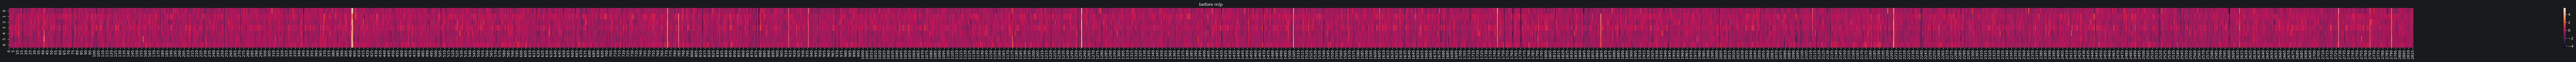

In [263]:
_h = h[0].detach().cpu().to(torch.float32).numpy()

plt.figure(figsize=(150, 2))
plt.title(f"before mlp") 
sns.heatmap(_h)
plt.show()

In [264]:
h = block.mlp.act(h)                # GELU (или иная, см. config.activation_function)
print(h)
print(h.shape)

tensor([[[-0.1670,  0.0170, -0.1553,  ..., -0.1562, -0.1592,  0.3418],
         [-0.1641,  0.1562,  0.1504,  ...,  0.0087,  0.0028,  0.0238],
         [-0.1611,  0.1748, -0.1680,  ..., -0.0383,  0.4004, -0.1436],
         ...,
         [-0.1406,  0.0547, -0.1387,  ..., -0.1348, -0.1533, -0.1289],
         [-0.0830, -0.1523, -0.1572,  ..., -0.1143, -0.1514, -0.0952],
         [-0.1699, -0.1689, -0.0486,  ..., -0.1006, -0.1436, -0.1689]]],
       dtype=torch.bfloat16, grad_fn=<MulBackward0>)
torch.Size([1, 7, 2816])


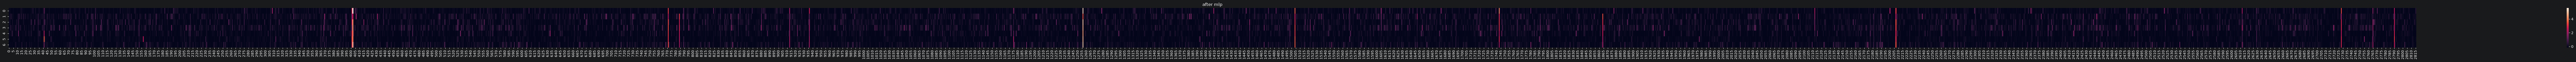

In [265]:
_h = h[0].detach().cpu().to(torch.float32).numpy()

plt.figure(figsize=(150, 2))
plt.title(f"after mlp") 
sns.heatmap(_h)
plt.show()

In [266]:
#import numpy as np

#np.savetxt(SAMPLES_DIR + sample_label+".txt", _h)


In [267]:

mlp_out = block.mlp.c_proj(h)       # intermediate -> embed_dim

print("mlp_out shape:", mlp_out.shape)

mlp_out shape: torch.Size([1, 7, 704])


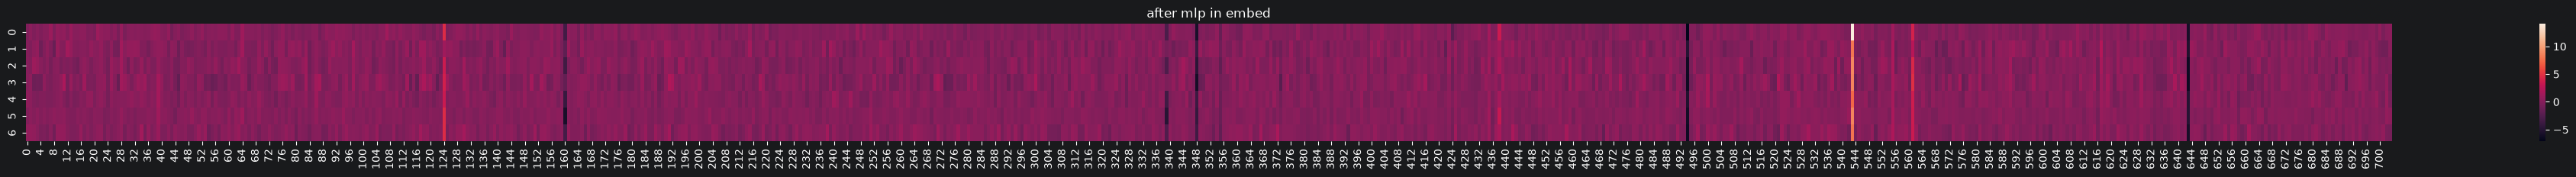

In [268]:
_h = mlp_out[0].detach().cpu().to(torch.float32).numpy()

plt.figure(figsize=(50, 2))
plt.title(f"after mlp in embed") 
sns.heatmap(_h)
plt.show()

In [269]:
# --- Шаг 11. Второй residual connection -- итог одного блока ---
manual_l0 = residual2 + mlp_out

print("max abs diff vs hs[1] (эталон от model()):",
      (manual_l0.float() - l0.float()).abs().max().item())
manual_l0
manual_l0.shape


max abs diff vs hs[1] (эталон от model()): 0.0


torch.Size([1, 7, 704])

In [270]:
# --- Шаг 12. Если это последний блок: финальный LayerNorm + lm_head ---
# Внимание: применимо только если в модели РОВНО num_hidden_layers блоков и
# вы вручную прогнали их все. Если блоков больше одного -- сначала повторите
# шаги 2-11 для каждого следующего model.transformer.h[i], передавая manual_l0 дальше как x.

if len(model.transformer.h) == 1:
    final_norm = model.transformer.ln_f(manual_l0)
    logits_manual = model.lm_head(final_norm)

    print("max abs diff vs outputs.logits (эталон):",
          (logits_manual.float() - outputs.logits.float()).abs().max().item())
else:
    print(f"В модели {len(model.transformer.h)} блоков -- это лишь блок 0. "
          f"Чтобы свериться с outputs.logits, нужно прогнать все блоки по очереди.")

В модели 11 блоков -- это лишь блок 0. Чтобы свериться с outputs.logits, нужно прогнать все блоки по очереди.


In [271]:
final_norm = model.transformer.ln_f(manual_l0)
logits_manual = model.lm_head(final_norm)

In [272]:
lprobs = F.softmax(logits_manual[0, -1], dim=-1)  # для последней позиции — это и есть "что предскажет модель дальше"
top_k = 15
top_probs, top_ids = torch.topk(probs, top_k)
top_tokens = tokenizer.convert_ids_to_tokens(top_ids.tolist())

print(f"\nПромпт: {prompt!r}")
print(f"Топ-{top_k} предсказаний следующего токена:\n")
for tok, p in zip(top_tokens, top_probs.tolist()):
    # убираем Ġ для читаемости, помечая что это начало нового слова
    display_tok = tok.replace("Ġ", "▸") if tok.startswith("Ġ") else tok
    bar = "█" * int(p * 50)
    print(f"  {display_tok!r:15s} {p:.4f}  {bar}")


Промпт: 'Bears eat honey because of '
Топ-15 предсказаний следующего токена:

  '▸âĢ'           0.0447  ██
  'ics'           0.0262  █
  'ery'           0.0231  █
  'ired'          0.0140  
  'ites'          0.0096  
  'icon'          0.0093  
  '▸mar'          0.0068  
  's'             0.0064  
  'âĢ'            0.0062  
  'ick'           0.0059  
  'S'             0.0059  
  'its'           0.0052  
  'ibr'           0.0043  
  '▸$'            0.0043  
  'ik'            0.0040  
